<a href="https://colab.research.google.com/github/dulibarri777-cpu/financial-ledger-audit/blob/main/Milestone_2_SQL_Financial_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

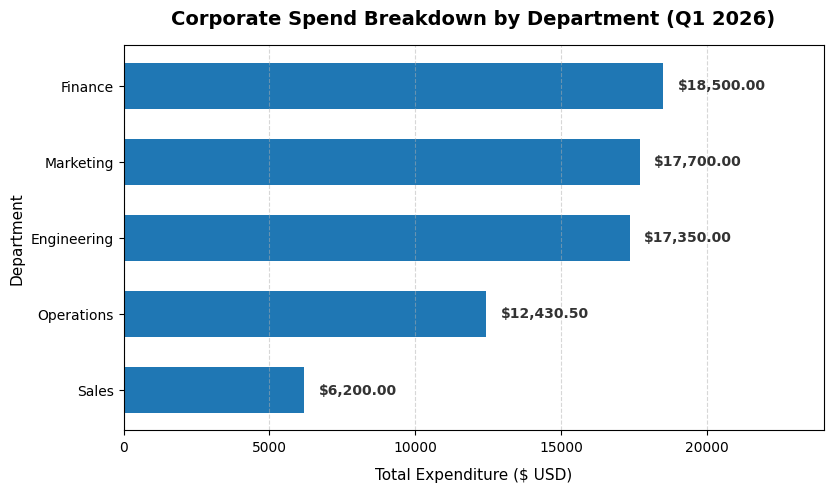

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Connect to in-memory SQL database
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE general_ledger (
    transaction_id TEXT,
    department TEXT,
    vendor TEXT,
    amount REAL
)
""")

# 2. Seed corporate ledger transactions
data = [
    ('TXN-101', 'Engineering', 'Amazon Web Services', 14250.00),
    ('TXN-102', 'Marketing', 'Google Ads', 8500.00),
    ('TXN-103', 'Operations', 'Staples', 430.50),
    ('TXN-104', 'Sales', 'Salesforce', 6200.00),
    ('TXN-105', 'Finance', 'Deloitte Advisory', 18500.00),
    ('TXN-106', 'Engineering', 'GitHub Enterprise', 3100.00),
    ('TXN-107', 'Marketing', 'Meta Platforms', 9200.00),
    ('TXN-108', 'Operations', 'WeWork Facilities', 12000.00)
]
cursor.executemany("INSERT INTO general_ledger VALUES (?, ?, ?, ?)", data)
conn.commit()

# 3. SQL Aggregation Query (GROUP BY department)
query = """
SELECT department, SUM(amount) AS total_spend
FROM general_ledger
GROUP BY department
ORDER BY total_spend ASC;
"""
df_chart = pd.read_sql_query(query, conn)

# 4. Generate the Corporate Spend Breakdown Chart
plt.figure(figsize=(10, 5))
bars = plt.barh(df_chart['department'], df_chart['total_spend'], color='#1f77b4', height=0.6)

plt.title('Corporate Spend Breakdown by Department (Q1 2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Expenditure ($ USD)', fontsize=11, labelpad=10)
plt.ylabel('Department', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, 24000)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 500, bar.get_y() + bar.get_height()/2, f"${width:,.2f}",
             va='center', fontsize=10, fontweight='bold', color='#333333')

plt.subplots_adjust(left=0.2, right=0.9)
plt.show()